In [2]:
import json
import os
import re
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

from gensim.models import Word2Vec
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split

In [3]:
BASE_DIR = Path.cwd()
DATA_DIR = os.path.join(BASE_DIR, "data")
DATA_PATH = os.path.join(DATA_DIR, "ori_pqal.json")

LABEL2ID = {"yes": 0, "no": 1, "maybe": 2}
ID2LABEL = {0: "yes", 1: "no", 2: "maybe"}

In [4]:
def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

In [5]:
def simple_tokenize(text):
    text = text.lower()
    tokens = re.findall(r"\b\w+\b", text)
    return tokens

def build_text(example):
    question = example["QUESTION"]
    contexts = " ".join(example["CONTEXTS"])
    return question + " " + contexts

In [6]:
def dataset_to_lists(dataset_dict):
    pmids = []
    texts = []
    labels = []

    for pmid, example in dataset_dict.items():
        text = build_text(example)
        label = example["final_decision"]

        pmids.append(pmid)
        texts.append(text)
        labels.append(LABEL2ID[label])

    return pmids, texts, np.array(labels)

In [7]:
def train_word2vec(tokenized_texts, vector_size=100, window=5, min_count=1):
    model = Word2Vec(
        sentences=tokenized_texts,
        vector_size=vector_size,
        window=window,
        min_count=min_count,
        workers=4,
        sg=1
    )
    return model

def sentence_vector(tokens, w2v_model, vector_size=100):
    vectors = []
    for token in tokens:
        if token in w2v_model.wv:
            vectors.append(w2v_model.wv[token])

    if len(vectors) == 0:
        return np.zeros(vector_size)

    return np.mean(vectors, axis=0)

def texts_to_vectors(texts, w2v_model, vector_size=100):
    tokenized = [simple_tokenize(text) for text in texts]
    vectors = np.array([
        sentence_vector(tokens, w2v_model, vector_size=vector_size)
        for tokens in tokenized
    ])
    return vectors

In [8]:
def main():
    data = load_json(DATA_PATH)
    pmids, texts, labels = dataset_to_lists(data)

    # step sampling
    X_train_texts, X_test_texts, y_train, y_test = train_test_split(
        texts,
        labels,
        test_size=0.3,
        random_state=42,
        stratify=labels
    )

    # Word2Vec
    tokenized_train = [simple_tokenize(text) for text in X_train_texts]
    w2v_model = train_word2vec(tokenized_train, vector_size=100)

    X_train = texts_to_vectors(X_train_texts, w2v_model, vector_size=100)
    X_test = texts_to_vectors(X_test_texts, w2v_model, vector_size=100)

    # Logistic Regression
    log_model = LogisticRegression(max_iter=1000)
    log_model.fit(X_train, y_train)
    log_pred = log_model.predict(X_test)

    log_acc = accuracy_score(y_test, log_pred)
    log_f1 = f1_score(y_test, log_pred, average="macro")

    # SVM
    svm_model = SVC(kernel="linear")
    svm_model.fit(X_train, y_train)
    svm_pred = svm_model.predict(X_test)

    svm_acc = accuracy_score(y_test, svm_pred)
    svm_f1 = f1_score(y_test, svm_pred, average="macro")

    print("=== 70/30 Split Results ===")
    print(f"Train size: {len(X_train_texts)}")
    print(f"Test size: {len(X_test_texts)}")
    print(f"Logistic Regression -> Accuracy: {log_acc:.4f}, Macro-F1: {log_f1:.4f}")
    print(f"SVM                 -> Accuracy: {svm_acc:.4f}, Macro-F1: {svm_f1:.4f}")

    from sklearn.metrics import confusion_matrix, classification_report

    print("\n=== Logistic Classification Report ===")
    print(classification_report(y_test, log_pred, target_names=["yes", "no", "maybe"]))

    print("\n=== SVM Classification Report ===")
    print(classification_report(y_test, svm_pred, target_names=["yes", "no", "maybe"]))

    plot_conf_matrix(y_test, log_pred, ["yes", "no", "maybe"], "Logistic Regression Confusion Matrix")
    plot_conf_matrix(y_test, svm_pred, ["yes", "no", "maybe"], "SVM Confusion Matrix")

    plot_metric_bar(log_acc, log_f1, svm_acc, svm_f1)

In [9]:
def plot_conf_matrix(y_true, y_pred, labels, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(values_format="d")
    plt.title(title)
    plt.show()

def plot_metric_bar(log_acc, log_f1, svm_acc, svm_f1):
    models = ["Logistic Regression", "SVM"]
    acc_values = [log_acc, svm_acc]
    f1_values = [log_f1, svm_f1]

    x = np.arange(len(models))
    width = 0.35

    plt.figure(figsize=(8, 5))
    plt.bar(x - width/2, acc_values, width, label="Accuracy")
    plt.bar(x + width/2, f1_values, width, label="Macro-F1")

    plt.xticks(x, models)
    plt.ylim(0, 1)
    plt.ylabel("Score")
    plt.title("Model Performance Comparison")
    plt.legend()
    plt.show()

=== 70/30 Split Results ===
Train size: 700
Test size: 300
Logistic Regression -> Accuracy: 0.5567, Macro-F1: 0.2617
SVM                 -> Accuracy: 0.5533, Macro-F1: 0.2375

=== Logistic Classification Report ===
              precision    recall  f1-score   support

         yes       0.56      0.98      0.71       166
          no       0.50      0.04      0.07       101
       maybe       0.00      0.00      0.00        33

    accuracy                           0.56       300
   macro avg       0.35      0.34      0.26       300
weighted avg       0.48      0.56      0.42       300


=== SVM Classification Report ===
              precision    recall  f1-score   support

         yes       0.55      1.00      0.71       166
          no       0.00      0.00      0.00       101
       maybe       0.00      0.00      0.00        33

    accuracy                           0.55       300
   macro avg       0.18      0.33      0.24       300
weighted avg       0.31      0.55      0.39

D:\Anaconda\envs\torchgpu\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\Anaconda\envs\torchgpu\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\Anaconda\envs\torchgpu\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\Anaconda\envs\torchgpu

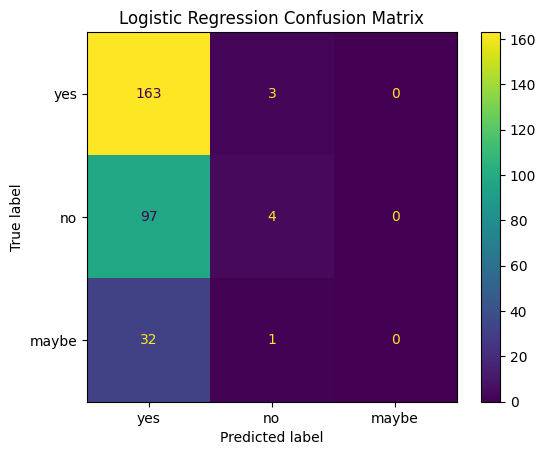

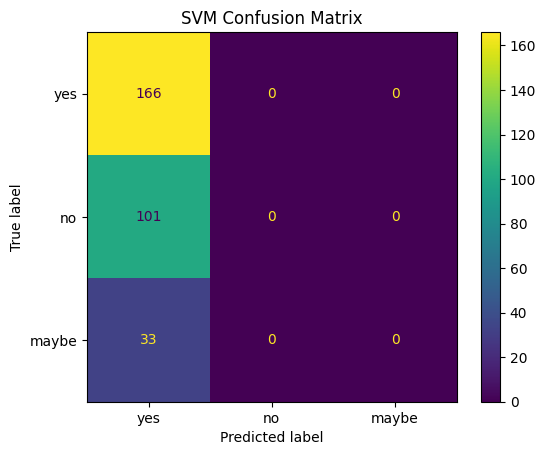

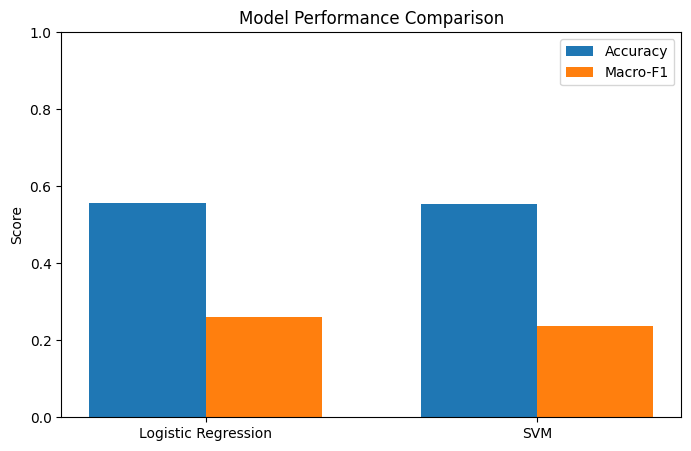

In [10]:
main()